# Style Bias 


What it does:

Data Loading: Handles DeepFashion-style CSVs containing image paths, labels, and style splits.
CLIP Evaluation: Runs zero-shot classification using CLIP.
Style Gap Analysis: Compares performance between catalog_like and less_curated data.
Preprocessing: Includes a background-removal step to test its impact on results.
Prompt Testing: Measures how sensitive the model is to different prompt variations.
Visualization: Uses t-SNE to map embeddings and calculate style separability.
Outputs: Generates summary statistics and publication-quality figures.

In [ ]:
import os

try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')
    ZIP_PATH = "/content/drive/MyDrive/dsresearch/img_highres.zip"
    OUT_DIR = "/content/deepfashion_data"
    if os.path.exists(ZIP_PATH):
        os.makedirs(OUT_DIR, exist_ok=True)
        !if [ ! -d "/content/deepfashion_data/img_highres" ]; then unzip -q "$ZIP_PATH" -d "$OUT_DIR"; fi
        print("Unzip step finished.")
    else:
        print("ZIP_PATH not found. Skip unzip or update the path.")
else:
    print("Not running in Colab. Skip mount/unzip.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Unzip step finished.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
CSV_PATH = "/content/drive/MyDrive/dsresearch/outputs/deepfashion_sleeve_with_style.csv"
IMAGE_ROOT = "/content/deepfashion_data/img_highres"

STYLE_GAP_N = 2000      # style-gap evaluation
INTERVENTION_N = 200    # intervention
EMBED_N = 300           # embedding analysis

print("CSV exists:", os.path.exists(CSV_PATH))
print("IMAGE_ROOT exists:", os.path.exists(IMAGE_ROOT))

Device: cuda
CSV exists: True
IMAGE_ROOT exists: True


In [ ]:
assert os.path.exists(CSV_PATH), f"CSV not found: {CSV_PATH}"
df = pd.read_csv(CSV_PATH)
required_cols = {"image_path", "label", "style_split"}
missing = required_cols - set(df.columns)
assert not missing, f"Missing required columns: {missing}"
df = df.dropna(subset=["image_path", "label", "style_split"]).reset_index(drop=True)

def resolve_image_path(p: str) -> str:
    p = str(p)
    if os.path.exists(p):
        return p

    base = os.path.basename(p)
    candidate = os.path.join(IMAGE_ROOT, base)
    if os.path.exists(candidate):
        return candidate

    marker = "img_highres/"
    if marker in p:
        tail = p.split(marker, 1)[1]
        candidate = os.path.join(IMAGE_ROOT, tail)
        if os.path.exists(candidate):
            return candidate

    return p

df["image_path"] = df["image_path"].apply(resolve_image_path)
df["path_exists"] = df["image_path"].apply(os.path.exists)

valid_df = df[df["path_exists"]].copy().reset_index(drop=True)

print("Rows before path filter:", len(df))
print("Rows after path filter:", len(valid_df))
print("Valid image ratio:", round(len(valid_df) / max(len(df), 1), 4))
print("\nLabel distribution:")
print(valid_df["label"].value_counts())
print("\nStyle distribution:")
print(valid_df["style_split"].value_counts())

df = valid_df
assert len(df) > 0, "No valid images found after path resolution."

Rows before path filter: 20000
Rows after path filter: 20000
Valid image ratio: 1.0

Label distribution:
label
sleeveless      10409
long sleeve      6117
short sleeve     3474
Name: count, dtype: int64

Style distribution:
style_split
less_curated    12102
catalog_like     7898
Name: count, dtype: int64


In [ ]:
# 3. Label mapping
class_names = sorted(df["label"].unique())
label2id = {c: i for i, c in enumerate(class_names)}
id2label = {i: c for c, i in label2id.items()}

df["label_id"] = df["label"].map(label2id)

print("Num classes:", len(class_names))
print("Classes:", class_names)

Num classes: 3
Classes: ['long sleeve', 'short sleeve', 'sleeveless']


In [ ]:
from transformers import CLIPProcessor, CLIPModel

class CLIPWrapper:
    def __init__(self, model_id: str = "openai/clip-vit-base-patch32"):
        self.model = CLIPModel.from_pretrained(model_id).to(device)
        self.processor = CLIPProcessor.from_pretrained(model_id)
        self.model.eval()

    def predict(self, image_paths, prompts):
        images = [Image.open(p).convert("RGB") for p in image_paths]
        inputs = self.processor(
            text=prompts,
            images=images,
            return_tensors="pt",
            padding=True
        ).to(device)

        with torch.no_grad():
            logits = self.model(**inputs).logits_per_image

        return logits.detach().cpu().numpy()

    def embed(self, image):
        inputs = self.processor(images=image, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = self.model.vision_model(pixel_values=inputs["pixel_values"])
            emb = outputs.pooler_output  # (1, hidden_dim)

        emb = emb / emb.norm(dim=-1, keepdim=True)
        return emb.detach().cpu().numpy()

model = CLIPWrapper()
print("Model ready.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Model ready.


In [ ]:
from sklearn.metrics import accuracy_score

def style_gap(df_in: pd.DataFrame, model: CLIPWrapper):
    prompts = [f"a photo of a {c} clothing item" for c in class_names]
    preds, gts, styles = [], [], []

    for i in tqdm(range(0, len(df_in), 32), desc="style_gap"):
        batch = df_in.iloc[i:i+32]
        logits = model.predict(batch["image_path"].tolist(), prompts)
        pred = logits.argmax(axis=1)

        preds.extend(pred.tolist())
        gts.extend(batch["label_id"].tolist())
        styles.extend(batch["style_split"].tolist())

    preds = np.array(preds)
    gts = np.array(gts)
    styles = np.array(styles)

    cat_mask = styles == "catalog_like"
    less_mask = styles == "less_curated"

    acc_cat = accuracy_score(gts[cat_mask], preds[cat_mask]) if cat_mask.any() else np.nan
    acc_less = accuracy_score(gts[less_mask], preds[less_mask]) if less_mask.any() else np.nan

    class_gap = {}
    for c in np.unique(gts):
        idx_cat = cat_mask & (gts == c)
        idx_less = less_mask & (gts == c)

        if idx_cat.sum() > 10 and idx_less.sum() > 10:
            acc_c = (preds[idx_cat] == gts[idx_cat]).mean()
            acc_l = (preds[idx_less] == gts[idx_less]).mean()
            class_gap[id2label[c]] = float(acc_c - acc_l)

    return acc_cat, acc_less, class_gap

sample_df = df.sample(min(STYLE_GAP_N, len(df)), random_state=SEED).reset_index(drop=True)
acc_cat, acc_less, class_gap = style_gap(sample_df, model)

print("Catalog accuracy:", acc_cat)
print("Less-curated accuracy:", acc_less)
print("Style gap:", acc_cat - acc_less)

print("\nPer-class gaps:")
for k, v in class_gap.items():
    print(f"{k}: {v:.3f}")

style_gap: 100%|██████████| 63/63 [01:27<00:00,  1.39s/it]

Catalog accuracy: 0.7602905569007264
Less-curated accuracy: 0.7367972742759795
Style gap: 0.023493282624746925

Per-class gaps:
long sleeve: -0.053
short sleeve: -0.043
sleeveless: 0.078


In [ ]:
PROMPTS = {
    "base": lambda c: f"a photo of a {c} clothing item",
    "focused": lambda c: f"a clothing item with {c} attribute",
}

def prompt_test(df_in: pd.DataFrame):
    results = {}

    for name, fn in PROMPTS.items():
        prompts = [fn(c) for c in class_names]
        margins = []
        preds, gts = [], []

        for i in tqdm(range(0, len(df_in), 32), desc=f"prompt_{name}"):
            batch = df_in.iloc[i:i+32]
            logits = model.predict(batch["image_path"].tolist(), prompts)
            pred = logits.argmax(axis=1)

            for j in range(len(batch)):
                gt = batch["label_id"].iloc[j]
                correct = logits[j][gt]
                wrong = np.delete(logits[j], gt).max()
                margins.append(float(correct - wrong))

            preds.extend(pred.tolist())
            gts.extend(batch["label_id"].tolist())

        results[name] = {
            "acc": float(accuracy_score(gts, preds)),
            "margin": float(np.mean(margins))
        }

    return results

prompt_results = prompt_test(sample_df)
print(prompt_results)

prompt_focused: 100%|██████████| 63/63 [01:10<00:00,  1.11s/it]

{'base': {'acc': 0.7465, 'margin': 1.28886990070343}, 'focused': {'acc': 0.756, 'margin': 1.0168482036590576}}


In [ ]:
import sys
import subprocess
from io import BytesIO

def ensure_rmbg():
    try:
        import rembg
        return True
    except Exception:
        print("Installing rembg and onnxruntime ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "rembg", "onnxruntime"])
        import rembg  
        return True

ensure_rmbg()
from rembg import remove 

def remove_bg(image_path: str):
    img = Image.open(image_path).convert("RGBA")
    out = remove(img)
    if isinstance(out, Image.Image):
        rgba = out.convert("RGBA")
    else:
        rgba = Image.open(BytesIO(out)).convert("RGBA")
    canvas = Image.new("RGBA", rgba.size, (255, 255, 255, 255))
    merged = Image.alpha_composite(canvas, rgba).convert("RGB")
    return merged

def intervention(df_in: pd.DataFrame, n: int = 200):
    sample = df_in.sample(min(n, len(df_in)), random_state=SEED).reset_index(drop=True)
    prompts = [f"a photo of a {c} clothing item" for c in class_names]

    sims = []
    pred_change = 0
    total = 0
    tmp_path = "/tmp/style_bias_bg_removed.png"

    for p in tqdm(sample["image_path"], desc="intervention"):
        try:
            orig = Image.open(p).convert("RGB")
            mod = remove_bg(p)
            e1 = np.asarray(model.embed(orig)).squeeze()
            e2 = np.asarray(model.embed(mod)).squeeze()
            sim = float(np.dot(e1, e2)) 
            sims.append(sim)

            mod.save(tmp_path)
            logits1 = model.predict([p], prompts)[0]
            logits2 = model.predict([tmp_path], prompts)[0]

            if int(logits1.argmax()) != int(logits2.argmax()):
                pred_change += 1
            total += 1

        except Exception as e:
            print("Fail:", p, e)
            continue

    if total == 0:
        print("No valid samples processed.")
        return [], np.nan

    return sims, pred_change / total

sims, change_rate = intervention(df, n=INTERVENTION_N)
print("Mean similarity:", np.mean(sims) if len(sims) else np.nan)
print("Prediction change rate:", change_rate)

Installing rembg and onnxruntime ...


intervention:   0%|          | 0/200 [00:00<?, ?it/s]Downloading data from 'https://github.com/danielgatis/rembg/releases/download/v0.0.0/u2net.onnx' to file '/root/.u2net/u2net.onnx'.


  0%|                                               | 0.00/176M [00:00<?, ?B/s]

intervention: 100%|██████████| 200/200 [10:33<00:00,  3.17s/it]

Mean similarity: 0.9513903078436852
Prediction change rate: 0.07


collect_embeddings: 100%|██████████| 300/300 [00:41<00:00,  7.25it/s]
Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7c5ba00d0540>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 379, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: /usr/loc

Collected embeddings: 300


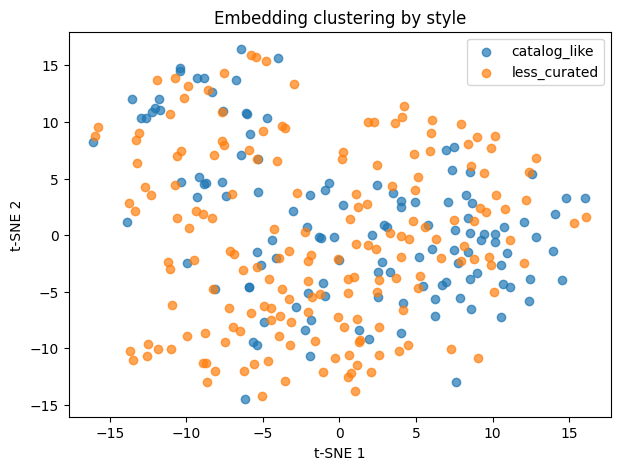

Style clustering score: 0.002950961235910654


In [ ]:
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

def collect_embeddings(df_in: pd.DataFrame, n: int = 300):
    sample = df_in.sample(min(n, len(df_in)), random_state=SEED).reset_index(drop=True)
    embs, styles = [], []

    for _, row in tqdm(sample.iterrows(), total=len(sample), desc="collect_embeddings"):
        try:
            img = Image.open(row["image_path"]).convert("RGB")
            emb = model.embed(img)
            embs.append(np.asarray(emb).squeeze())
            styles.append(row["style_split"])
        except Exception as e:
            print("Fail:", row["image_path"], e)
            continue

    print("Collected embeddings:", len(embs))
    return np.array(embs), styles

embs, styles = collect_embeddings(df, n=EMBED_N)

sil_score = np.nan
if len(embs) < 10:
    print("Too few embeddings.")
else:
    perplexity = min(30, len(embs) - 1)
    proj = TSNE(n_components=2, perplexity=perplexity, random_state=SEED).fit_transform(embs)

    plt.figure(figsize=(7, 5))
    for s in sorted(set(styles)):
        idx = [i for i in range(len(styles)) if styles[i] == s]
        plt.scatter(proj[idx, 0], proj[idx, 1], label=s, alpha=0.7)
    plt.legend()
    plt.title("Embedding clustering by style")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.show()

    style_labels = np.array([0 if s == "catalog_like" else 1 for s in styles])
    if len(set(style_labels)) > 1:
        sil_score = float(silhouette_score(embs, style_labels))
        print("Style clustering score:", sil_score)
    else:
        print("Only one style present.")

In [ ]:
style_gap_value = float(acc_cat - acc_less)

print("=== FINAL RESULTS ===")
print("Style Gap:", style_gap_value)
print("Intervention Similarity:", float(np.mean(sims)) if len(sims) else np.nan)
print("Prediction Change Rate:", change_rate)
print("Embedding Style Score:", sil_score)
print("Prompt Results:", prompt_results)

print("""
=== INTERPRETATION ===

1. Style gap: performance differs across presentation styles.
2. Background intervention: predictions can change under style-related visual edits.
3. Embedding clustering: if silhouette is near zero, global style separation is weak.

CONCLUSION:
The model may rely on style-sensitive cues rather than purely robust attribute understanding.
""")

=== FINAL RESULTS ===
Style Gap: 0.023493282624746925
Intervention Similarity: 0.9513903078436852
Prediction Change Rate: 0.07
Embedding Style Score: 0.002950961235910654
Prompt Results: {'base': {'acc': 0.7465, 'margin': 1.28886990070343}, 'focused': {'acc': 0.756, 'margin': 1.0168482036590576}}

=== INTERPRETATION ===

1. Style gap: performance differs across presentation styles.
2. Background intervention: predictions can change under style-related visual edits.
3. Embedding clustering: if silhouette is near zero, global style separation is weak.

CONCLUSION:
The model may rely on style-sensitive cues rather than purely robust attribute understanding.



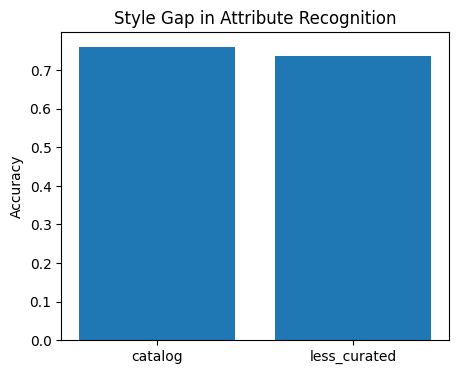

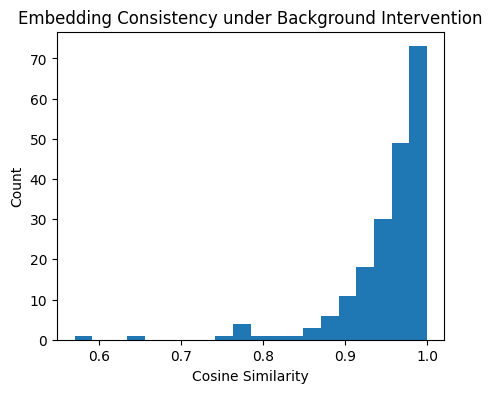

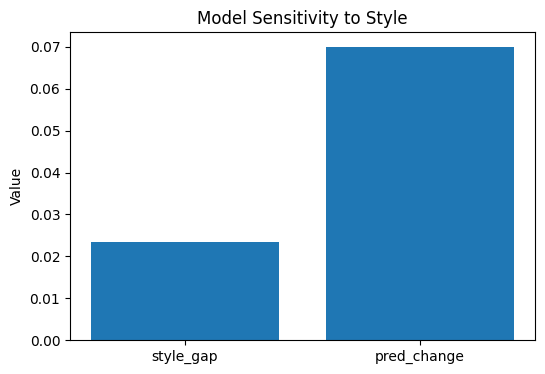

In [ ]:

plt.figure(figsize=(5, 4))
plt.bar(["catalog", "less_curated"], [acc_cat, acc_less])
plt.title("Style Gap in Attribute Recognition")
plt.ylabel("Accuracy")
plt.show()
plt.figure(figsize=(5, 4))
plt.hist(sims, bins=20)
plt.title("Embedding Consistency under Background Intervention")
plt.xlabel("Cosine Similarity")
plt.ylabel("Count")
plt.show()
plt.figure(figsize=(6, 4))
plt.bar(
    ["style_gap", "pred_change"],
    [style_gap_value, change_rate]
)
plt.title("Model Sensitivity to Style")
plt.ylabel("Value")
plt.show()